<a href="https://colab.research.google.com/github/matthewmorrice/Machine-Learning-Diagnosis-of-Diabetic-Eye-Disease-/blob/main/CNN_Modelling_Optuna_tuning_and_Data_augmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Import data to extract image paths and labels**

In [ ]:
from google.colab import drive

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython import get_ipython
from IPython.display import display

# Import dataset
data = pd.read_csv('/content/drive/MyDrive/AI Coursework/Biomarker_Clinical_Data_Images_2.csv (17KB)')
display(data)

base_dir = '/content/drive/MyDrive/AI Coursework/Extracted Images'
image_paths = data.iloc[:,0]
full_paths = []

for path in image_paths:
  path = base_dir + path
  full_paths.append(path)

disease_labels = data.iloc[:,20]

images = []
labels = []

import cv2

# Load images and labels
for path, label in zip(full_paths, disease_labels):
    img = cv2.imread(path)

    if img is not None:  # Check if the image was successfully loaded
        img = cv2.resize(img, (224, 224))  # Resize to desired dimensions
        images.append(img)
        labels.append(label)
    else:
        print(f"Warning: Could not load image at path {path}")

# Convert lists to NumPy arrays
images = np.array(images)
labels = np.array(labels)

images = images.astype('float32')  # Convert to float32
images /= 255.0  # Normalize to [0, 1]

print(f"Loaded {len(images)} images and {len(labels)} labels.")

from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

label_encoder = LabelEncoder()
labels = label_encoder.fit_transform(labels)
labels = to_categorical(labels) # Convert labels to one-hot encoding


,Path,Biomarker 1,Biomarker 2,Biomarker 3,Biomarker 4,Biomarker 5,Biomarker 6,Biomarker 7,Biomarker 8,Biomarker 9,...,Biomarker 11,Biomarker 12,Biomarker 13,Biomarker 14,Biomarker 15,Biomarker 16,Eye_ID,BCVA,CST,Disease Label
0,/TREX DME/GILA/0201GOD/V1/OD/TREXJ_000024.tif,0,0,0,0,1,0,1,0,0,...,1,1,1,0,0,0,1,61,575,DME
1,/TREX DME/GILA/0201GOD/V22/OD/TREX_DME_000024.tif,0,1,0,0,1,0,1,0,0,...,0,1,0,0,0,0,1,71,241,DME
2,/TREX DME/GILA/0203GOS/V1/OS/TREXS_000024.tif,0,0,0,0,1,0,1,0,0,...,1,1,0,0,0,0,2,80,392,DME
3,/TREX DME/GILA/0203GOS/V15/OS/TREX_DME_000024.tif,0,0,0,0,1,0,0,0,1,...,0,0,0,0,0,0,2,85,270,DME
4,/TREX DME/GILA/0204GOS/V1/OS/TREXD_000024.tif,0,0,0,0,1,1,0,0,0,...,1,1,0,0,0,0,3,62,539,DME
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
187,/Prime_FULL/02-044/W36/OS/24.tif,0,0,0,0,1,0,1,0,1,...,0,0,0,0,0,0,94,86,199,DR
188,/Prime_FULL/02-045/W0/OS/24.tif,0,0,0,0,1,0,0,0,0,...,1,1,1,0,0,0,95,74,302,DR
189,/Prime_FULL/02-045/W104/OS/24.tif,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,95,68,222,DR
190,/Prime_FULL/02-046/W0/OD/24.tif,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,96,89,283,DR


Loaded 187 images and 187 labels.


**Set Up CNN Model**

Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 14s 3s/step - accuracy: 0.6711 - loss: 1.9957 - val_accuracy: 0.5667 - val_loss: 1.6072
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 11s 206ms/step - accuracy: 0.6012 - loss: 1.5683 - val_accuracy: 0.6000 - val_loss: 1.4751
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 466ms/step - accuracy: 0.6954 - loss: 1.4279 - val_accuracy: 0.7000 - val_loss: 1.4015
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 232ms/step - accuracy: 0.7242 - loss: 1.3058 - val_accuracy: 0.8333 - val_loss: 1.2803
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 515ms/step - accuracy: 0.7532 - loss: 1.2719 - val_accuracy: 0.8333 - val_loss: 1.2099
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 259ms/step - accuracy: 0.7431 - loss: 1.1644 - val_accuracy: 0.8333 - val_loss: 1.1979
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 461ms/step - accuracy: 0.8138 - loss: 1.1278 - val_accuracy: 0.8333 - val_loss: 1.0931
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 230ms/step - accuracy: 0.8307 - loss: 1.0207 - val_accuracy: 0.8667 - va

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)                    │ (None, 224, 224, 96)        │           2,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 112, 112, 96)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 110, 110, 192)       │         166,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 55, 55, 192)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 580800)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 384)                 │     223,027,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 384)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 2)                   │             770 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 669,591,368 (2.49 GB)

 Trainable params: 223,197,122 (851.43 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 446,394,246 (1.66 GB)

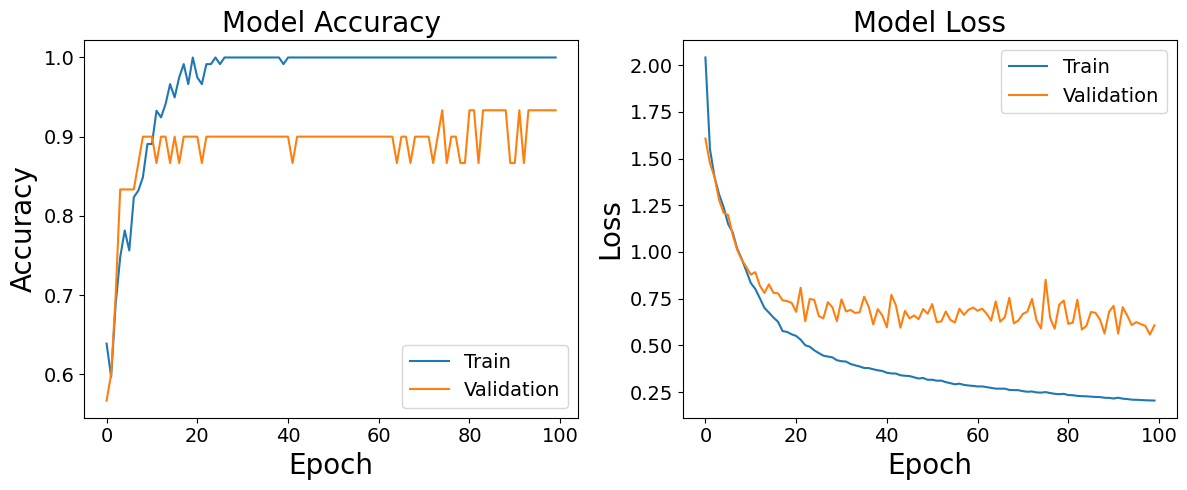

1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step
Accuracy: 0.7894736842105263
Precision: 0.8215384615384616
Recall: 0.7894736842105263
F1-Score: 0.7840909090909092
Average ROC AUC (OvR): 0.7894736842105263


In [ ]:
from keras.models import Sequential
from keras.layers import Dense, Conv2D, Flatten, MaxPool2D, Dropout
from keras.regularizers import l1, l2
from keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# Split the data into training and testing sets
images_train, images_test, labels_train, labels_test = train_test_split(
    images, labels, test_size=0.2, random_state=42)

img_rows = images.shape[1]
img_cols = images.shape[2]
img_channels = images.shape[3]
num_classes = labels.shape[1]
num_filters = 96

# Build the model
model = Sequential()
model.add(Conv2D(num_filters, kernel_size=3, activation='relu',
                 input_shape=(img_rows, img_cols, img_channels), padding = 'same',
                 dilation_rate = 2))#, kernel_regularizer=l1(0.01)))
model.add(MaxPool2D(2))
model.add(Conv2D(num_filters*2, kernel_size=3, activation='relu', kernel_regularizer=l2(0.0011114688286547925)))
model.add(MaxPool2D(2))
model.add(Flatten())
model.add(Dense(num_filters*4, activation='relu', kernel_regularizer=l2(0.0011114688286547925)))
model.add(Dropout(0.4))
model.add(Dense(num_classes, activation='softmax', kernel_regularizer=l2(0.00011114688286547925)))

# model.add(Conv2D(num_filters, kernel_size=3, activation='relu',
#                  input_shape=(img_rows, img_cols, img_channels), padding = 'same',
#                  dilation_rate = 2, kernel_regularizer=l1(0.01)))
# model.add(MaxPool2D(2))

# model.add(Conv2D(num_filters*2, kernel_size=3, activation='relu'))
# model.add(MaxPool2D(2))
# model.add(Conv2D(num_filters*4, kernel_size=3, activation='relu'))
# model.add(MaxPool2D(2))
# model.add(Conv2D(num_filters*16, kernel_size=3, activation='relu'))
# model.add(MaxPool2D(2))

# model.add(Flatten())
# model.add(Dropout(0.5))
# model.add(Dense(num_classes, activation='softmax', kernel_regularizer=l2(0.01)))

# Original: {'num_filters': 2(num_classes), 'dropout_rate': not included, 'learning rate': default}
# Best hyperparameters: {'num_filters': 64, 'dropout_rate': 0.5, 'learning_rate': 0.00019340055723859404}
# Best is trial 17 with value: 0.9473684430122375.
# Best hyperparameters: {'num_filters': 96, 'dropout_rate': 0.30000000000000004, 'learning_rate': 0.004175448911645524}
# Best is trial 50 with value: 0.9210526347160339.
# Best hyperparameters: {'num_filters': 128, 'dropout_rate': 0.5, 'learning_rate': 0.000327537895887467, 'num_conv_layers': 3, 'kernel_size': (3, 3)}

# Trial 6 finished with value: 0.7894737124443054 and parameters: {'num_filters': 96, 'dropout_rate': 0.4, 'learning_rate': 4.893049541904633e-05, 'num_conv_layers': 1, 'kernel_size': (3, 3), 'l2_reg': 0.00011114688286547925}. Best is trial 3 with value: 0.8947368264198303.
# Accuracy Volatility: 0.05203425305381234
# Loss Volatility: 0.07663184908094117
# Trial 8 finished with value: 0.8157894611358643 and parameters: {'num_filters': 96, 'dropout_rate': 0.4, 'learning_rate': 6.795437943260704e-05, 'num_conv_layers': 1, 'kernel_size': (5, 5), 'l2_reg': 0.00013255743051051084}. Best is trial 3 with value: 0.8947368264198303.
# Accuracy Volatility: 0.08962834689954162
# Loss Volatility: 0.08499667155596147
# Trial 13 finished with value: 0.7105262875556946 and parameters: {'num_filters': 32, 'dropout_rate': 0.30000000000000004, 'learning_rate': 1.0537714653158082e-05, 'num_conv_layers': 2, 'kernel_size': (3, 3), 'l2_reg': 0.0012096665030932115}. Best is trial 3 with value: 0.8947368264198303.
# Accuracy Volatility: 0.11130675566244849
# Loss Volatility: 0.055192297883607175

# Compile the model
model.compile(optimizer=Adam(learning_rate=4.893049541904633e-05), loss='categorical_crossentropy', metrics=['accuracy'])
# model.compile(optimizer=Adam(learning_rate=0.000327537895887467), loss='categorical_crossentropy', metrics=['accuracy'])

# Fit the model to the training data
history = model.fit(images_train, labels_train, validation_split=0.2, epochs=100)
history_original = history

# Evaluate the performance on the test data
evaluation_result = model.evaluate(images_test, labels_test)
print("Test Accuracy:", evaluation_result[1])

model.summary()

# Plotting the training and validation curves
plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy', fontsize=20)
plt.xlabel('Epoch', fontsize=20)
plt.ylabel('Accuracy', fontsize=20)
plt.legend(['Train', 'Validation'], loc='lower right', fontsize=14)
plt.tick_params(axis='both', which='major', labelsize=14)

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss', fontsize=20)
plt.xlabel('Epoch', fontsize=20)
plt.ylabel('Loss', fontsize=20)
plt.legend(['Train', 'Validation'], loc='upper right', fontsize=14)
plt.tick_params(axis='both', which='major', labelsize=14)

# Adjust layout to prevent overlapping
plt.tight_layout()

# Show the plot
plt.show()

labels_pred = model.predict(images_test)
labels_pred = np.argmax(labels_pred, axis=1)
labels_test = np.argmax(labels_test, axis=1)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

accuracy = accuracy_score(labels_test, labels_pred)
precision = precision_score(labels_test, labels_pred, average='weighted')  # Adjust 'average' as needed
recall = recall_score(labels_test, labels_pred, average='weighted')  # Adjust 'average' as needed
f1 = f1_score(labels_test, labels_pred, average='weighted')  # Adjust 'average' as needed
roc_auc = roc_auc_score(labels_test, labels_pred, multi_class='ovr')  # One-vs-Rest AUC

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1-Score: {f1}")
print(f"Average ROC AUC (OvR): {roc_auc}")

**Tune Model with Optuna**

In [ ]:
!pip install optuna
import optuna
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

labels_test = to_categorical(labels_test)

def calculate_volatility(validation_metric):
    # Standard deviation of the validation metric
    volatility = np.std(validation_metric)
    return volatility

def objective(trial):
  # Define hyperparameters to be tuned
  num_filters = trial.suggest_int('num_filters', 32, 128, step=32)
  dropout_rate = trial.suggest_float('dropout_rate', 0.2, 0.5, step=0.1)
  learning_rate = trial.suggest_float('learning_rate', 1e-5, 1e-2, log=True)
  num_conv_layers = trial.suggest_int('num_conv_layers', 1, 2)
  kernel_size = trial.suggest_categorical('kernel_size', [(3, 3), (5, 5)])
  l2_reg = trial.suggest_float('l2_reg', 0.0001, 0.1, log=True)

  # Build your CNN model
  model = Sequential()
  model.add(Conv2D(num_filters, kernel_size, activation='relu', input_shape=(img_rows, img_cols, img_channels)))
  model.add(MaxPooling2D((2, 2)))

  for i in range(num_conv_layers):
    model.add(Conv2D(num_filters * (2 ** i), kernel_size, activation='relu', kernel_regularizer=l2(l2_reg)))
    model.add(MaxPooling2D((2, 2)))

  model.add(Flatten())
  model.add(Dense(num_filters*2, activation='relu', kernel_regularizer=l2(l2_reg)))
  model.add(Dropout(dropout_rate))
  model.add(Dense(num_classes, activation='softmax'))

  # Compile the model
  model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                loss='categorical_crossentropy', metrics=['accuracy'])

  early_stopping = EarlyStopping(monitor='val_loss', patience=3)
  # Train the model
  history = model.fit(images_train, labels_train, epochs=30, validation_data=(images_test, labels_test), callbacks=[early_stopping])

  # Retrieve validation accuracy and calculate volatility
  val_accuracy = history.history['val_accuracy']
  val_loss = history.history['val_loss']
  accuracy_volatility = calculate_volatility(val_accuracy)
  loss_volatility = calculate_volatility(val_loss)
  print(f"Accuracy Volatility: {accuracy_volatility}")
  print(f"Loss Volatility: {loss_volatility}")

  # Return the validation accuracy
  return history.history['val_accuracy'][-1]

# Create an Optuna study
study = optuna.create_study(direction='maximize')  # Maximize validation accuracy

# Optimize the study
study.optimize(objective, n_trials=100)  # Run for 100 trials

# Get the best hyperparameters
best_params = study.best_params
print(f"Best hyperparameters: {best_params}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 364.4/364.4 kB 30.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.5/233.5 kB 22.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.6/78.6 kB 8.2 MB/s eta 0:00:00


[I 2025-01-19 11:23:32,057] A new study created in memory with name: no-name-3a2c8bab-dfd9-4134-ace5-f81640e15dad
/usr/local/lib/python3.11/dist-packages/optuna/distributions.py:524: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (3, 3) which is of type tuple.
  warnings.warn(message)
/usr/local/lib/python3.11/dist-packages/optuna/distributions.py:524: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (5, 5) which is of type tuple.
  warnings.warn(message)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 24s 3s/step - accuracy: 0.6415 - loss: 2.4847 - val_accuracy: 0.5000 - val_loss: 0.8198
Epoch 2/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 162ms/step - accuracy: 0.6389 - loss: 0.8217 - val_accuracy: 0.6579 - val_loss: 0.8220
Epoch 3/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step - accuracy: 0.6770 - loss: 0.7899 - val_accuracy: 0.5000 - val_loss: 0.9487
Epoch 4/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.6138 - loss: 0.7394 - val_accuracy: 0.7105 - val_loss: 0.7197
Epoch 5/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 140ms/step - accuracy: 0.7848 - loss: 0.5976 - val_accuracy: 0.7105 - val_loss: 0.7128
Epoch 6/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 145ms/step - accuracy: 0.7755 - loss: 0.6077 - val_accuracy: 0.7632 - val_loss: 0.6052
Epoch 7/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 267ms/step - accuracy: 0.7730 - loss: 0.6158 - val_accuracy: 0.7105 - val_loss: 0.7035
Epoch 8/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.8523 - loss: 0.5066 - val_accuracy: 0.7895 - val_loss: 0.52

[I 2025-01-19 11:24:13,546] Trial 0 finished with value: 0.7894737124443054 and parameters: {'num_filters': 64, 'dropout_rate': 0.30000000000000004, 'learning_rate': 0.0007359151462748123, 'num_conv_layers': 1, 'kernel_size': (5, 5), 'l2_reg': 0.0004884937191686827}. Best is trial 0 with value: 0.7894737124443054.


Accuracy Volatility: 0.10606569246845114
Loss Volatility: 0.1285392854861817


...

Accuracy Volatility: 0.0996949748156574
Loss Volatility: 0.11943963075444838


/usr/local/lib/python3.11/dist-packages/optuna/distributions.py:524: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (3, 3) which is of type tuple.
  warnings.warn(message)
/usr/local/lib/python3.11/dist-packages/optuna/distributions.py:524: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (5, 5) which is of type tuple.
  warnings.warn(message)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30


[W 2025-01-19 11:38:25,255] Trial 22 failed with parameters: {'num_filters': 128, 'dropout_rate': 0.30000000000000004, 'learning_rate': 0.00016851144457083169, 'num_conv_layers': 2, 'kernel_size': (3, 3), 'l2_reg': 0.00018829847802405268} because of the following error: ResourceExhaustedError().
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/optuna/study/_optimize.py", line 197, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "<ipython-input-4-6041036ccbc5>", line 44, in objective
    history = model.fit(images_train, labels_train, epochs=30, validation_data=(images_test, labels_test), callbacks=[early_stopping])
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/keras/src/utils/traceback_utils.py", line 122, in error_handler
    raise e.with_traceback(filtered_tb) from None
  Fil

ResourceExhaustedError: Graph execution error:

Detected at node StatefulPartitionedCall defined at (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main

  File "<frozen runpy>", line 88, in _run_code

  File "/usr/local/lib/python3.11/dist-packages/colab_kernel_launcher.py", line 37, in <module>

  File "/usr/local/lib/python3.11/dist-packages/traitlets/config/application.py", line 992, in launch_instance

  File "/usr/local/lib/python3.11/dist-packages/ipykernel/kernelapp.py", line 619, in start

  File "/usr/local/lib/python3.11/dist-packages/tornado/platform/asyncio.py", line 195, in start

  File "/usr/lib/python3.11/asyncio/base_events.py", line 608, in run_forever

  File "/usr/lib/python3.11/asyncio/base_events.py", line 1936, in _run_once

  File "/usr/lib/python3.11/asyncio/events.py", line 84, in _run

  File "/usr/local/lib/python3.11/dist-packages/tornado/ioloop.py", line 685, in <lambda>

  File "/usr/local/lib/python3.11/dist-packages/tornad

optuna grid search to select hyperparameters

**10 epochs no early stopping:**

[I 2025-01-14 22:51:32,166] Trial 99 finished with value: 0.7105262875556946 and parameters: {'num_filters': 64, 'dropout_rate': 0.4, 'learning_rate': 0.00019442024002428379}. Best is trial 17 with value: 0.8947368264198303.

Best hyperparameters: {'num_filters': 64, 'dropout_rate': 0.5, 'learning_rate': 0.00019340055723859404}

**30 epochs, early stopping (patience 3):**

Epoch 13/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 120ms/step - accuracy: 1.0000 - loss: 0.0038 - val_accuracy: 0.9474 - val_loss: 0.2952
[I 2025-01-15 12:59:47,899] Trial 17 finished with value: 0.9473684430122375 and parameters: {'num_filters': 96, 'dropout_rate': 0.30000000000000004, 'learning_rate': 0.004175448911645524}. Best is trial 17 with value: 0.9473684430122375.

Epoch 9/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 126ms/step - accuracy: 1.0000 - loss: 0.0017 - val_accuracy: 0.8421 - val_loss: 0.7409
[I 2025-01-15 13:35:53,061] Trial 99 finished with value: 0.8421052694320679 and parameters: {'num_filters': 96, 'dropout_rate': 0.30000000000000004, 'learning_rate': 0.0003128704940416145}. Best is trial 17 with value: 0.9473684430122375.
Best hyperparameters: {'num_filters': 96, 'dropout_rate': 0.30000000000000004, 'learning_rate': 0.004175448911645524}

**Data Augmentation**

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


5/5 ━━━━━━━━━━━━━━━━━━━━ 48s 7s/step - accuracy: 0.5946 - loss: 1.9256 - val_accuracy: 0.6842 - val_loss: 1.5551
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 840ms/step - accuracy: 0.6360 - loss: 1.6117 - val_accuracy: 0.6842 - val_loss: 1.5020
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 795ms/step - accuracy: 0.6112 - loss: 1.5463 - val_accuracy: 0.7368 - val_loss: 1.4075
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 376ms/step - accuracy: 0.6597 - loss: 1.4286 - val_accuracy: 0.6316 - val_loss: 1.3663
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 511ms/step - accuracy: 0.6251 - loss: 1.3336 - val_accuracy: 0.7632 - val_loss: 1.2950
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 609ms/step - accuracy: 0.7134 - loss: 1.2604 - val_accuracy: 0.7632 - val_loss: 1.2168
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 426ms/step - accuracy: 0.7325 - loss: 1.2142 - val_accuracy: 0.7105 - val_loss: 1.1700
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 256ms/step - accuracy: 0.6753 - loss: 1.1916 - val_accuracy: 0.7105 - val_loss: 1.127

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 224, 224, 96)        │           2,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 112, 112, 96)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 110, 110, 192)       │         166,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 55, 55, 192)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 580800)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 384)                 │     223,027,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 384)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 2)                   │             770 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 669,591,368 (2.49 GB)

 Trainable params: 223,197,122 (851.43 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 446,394,246 (1.66 GB)

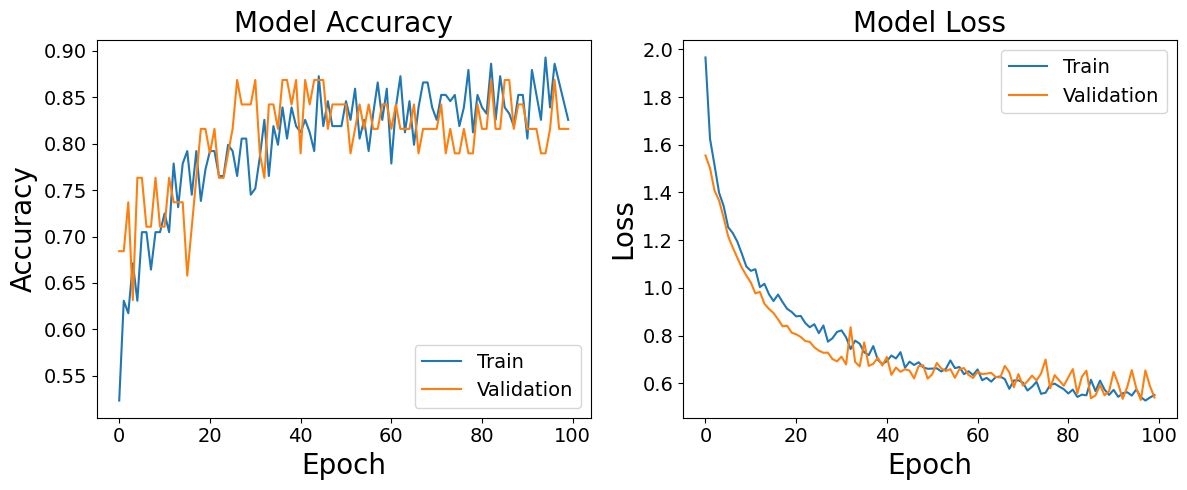

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 897ms/step
Accuracy: 0.8157894736842105
Precision: 0.8238636363636364
Recall: 0.8157894736842105
F1-Score: 0.8146341463414635
Average ROC AUC (OvR): 0.8157894736842105


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

def add_noise(image):
    # Add noise
    noise = np.random.normal(loc=0.0, scale=0.05, size=image.shape)  # Scale adjusts intensity
    noisy_image = image + noise
    # Clip the image to be within valid pixel range [0, 1]
    noisy_image = np.clip(noisy_image, 0., 1.)
    return noisy_image

# Augmentation configuration
train_datagen = ImageDataGenerator(
    rotation_range=10,
    # width_shift_range=0.2,
    # height_shift_range=0.2,
    # shear_range=0.2,
    zoom_range=0.5,
    horizontal_flip=True,
    # vertical_flip=True,
    fill_mode='nearest',
    preprocessing_function=add_noise
)

from keras.models import Sequential
from keras.layers import Dense, Conv2D, Flatten, MaxPool2D, Dropout
from keras.regularizers import l1, l2
from keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# Split the data into training and testing sets
images_train, images_test, labels_train, labels_test = train_test_split(
    images, labels, test_size=0.2, random_state=42)

img_rows = images.shape[1]
img_cols = images.shape[2]
img_channels = images.shape[3]
num_classes = labels.shape[1]
num_filters = 96

# # Build the model
# model = Sequential()
# model.add(Conv2D(num_filters, kernel_size=3, activation='relu',
#                  input_shape=(img_rows, img_cols, img_channels), padding = 'same',
#                  dilation_rate = 2, kernel_regularizer=l1(0.01)))
# model.add(MaxPool2D(2))
# model.add(Conv2D(num_filters*2, kernel_size=3, activation='relu', kernel_regularizer=l1(0.01)))
# model.add(MaxPool2D(2))
# model.add(Flatten())
# model.add(Dense(num_filters, activation='relu', kernel_regularizer=l2(0.01)))
# model.add(Dropout(0.3))
# model.add(Dense(num_classes, activation='softmax', kernel_regularizer=l2(0.01)))

# Build the model
model = Sequential()
model.add(Conv2D(num_filters, kernel_size=3, activation='relu',
                 input_shape=(img_rows, img_cols, img_channels), padding = 'same',
                 dilation_rate = 2))#, kernel_regularizer=l1(0.01)))
model.add(MaxPool2D(2))
model.add(Conv2D(num_filters*2, kernel_size=3, activation='relu', kernel_regularizer=l2(0.0011114688286547925)))
model.add(MaxPool2D(2))
model.add(Flatten())
model.add(Dense(num_filters*4, activation='relu', kernel_regularizer=l2(0.0011114688286547925)))
model.add(Dropout(0.4))
model.add(Dense(num_classes, activation='softmax', kernel_regularizer=l2(0.00011114688286547925)))

# Compile the model
model.compile(optimizer=Adam(learning_rate=4.893049541904633e-05), loss='categorical_crossentropy', metrics=['accuracy'])

# Fit the model to the training data
history = model.fit(train_datagen.flow(images_train, labels_train),
                    validation_data=(images_test, labels_test), epochs=50)#, validation_split=0.2)
history_augmented = history

# Evaluate the performance on the test data
evaluation_result = model.evaluate(images_test, labels_test)
print("Test Accuracy:", evaluation_result[1])

model.summary()

# Plotting the training and validation curves
plt.figure(figsize=(12, 5))


# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy', fontsize=20)
plt.xlabel('Epoch', fontsize=20)
plt.ylabel('Accuracy', fontsize=20)
plt.legend(['Train', 'Validation'], loc='lower right', fontsize=14)
plt.tick_params(axis='both', which='major', labelsize=14)

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss', fontsize=20)
plt.xlabel('Epoch', fontsize=20)
plt.ylabel('Loss', fontsize=20)
plt.legend(['Train', 'Validation'], loc='upper right', fontsize=14)
plt.tick_params(axis='both', which='major', labelsize=14)

# Adjust layout to prevent overlapping
plt.tight_layout()

# Show the plot
plt.show()


labels_pred = model.predict(images_test)
labels_pred = np.argmax(labels_pred, axis=1)
labels_test = np.argmax(labels_test, axis=1)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

accuracy = accuracy_score(labels_test, labels_pred)
precision = precision_score(labels_test, labels_pred, average='weighted')  # Adjust 'average' as needed
recall = recall_score(labels_test, labels_pred, average='weighted')  # Adjust 'average' as needed
f1 = f1_score(labels_test, labels_pred, average='weighted')  # Adjust 'average' as needed
roc_auc = roc_auc_score(labels_test, labels_pred, multi_class='ovr')  # One-vs-Rest AUC

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1-Score: {f1}")
print(f"Average ROC AUC (OvR): {roc_auc}")







In [ ]:
import pickle
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Specify the file path within your Drive
file_path = '/content/drive/My Drive/history_original.pkl'  # Choose your desired location

# Save the variable
with open(file_path, 'wb') as f:
    pickle.dump(history_original, f)

print(f"Variable 'history_original' saved to: {file_path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Variable 'history_original' saved to: /content/drive/My Drive/history_original.pkl


In [ ]:
import pickle
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Specify the file path
file_path = '/content/drive/My Drive/history_original.pkl'  # Use the same path as before

# Load the variable
with open(file_path, 'rb') as f:
    history_original = pickle.load(f)

print("Variable 'history_original' loaded.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Variable 'history_original' loaded.


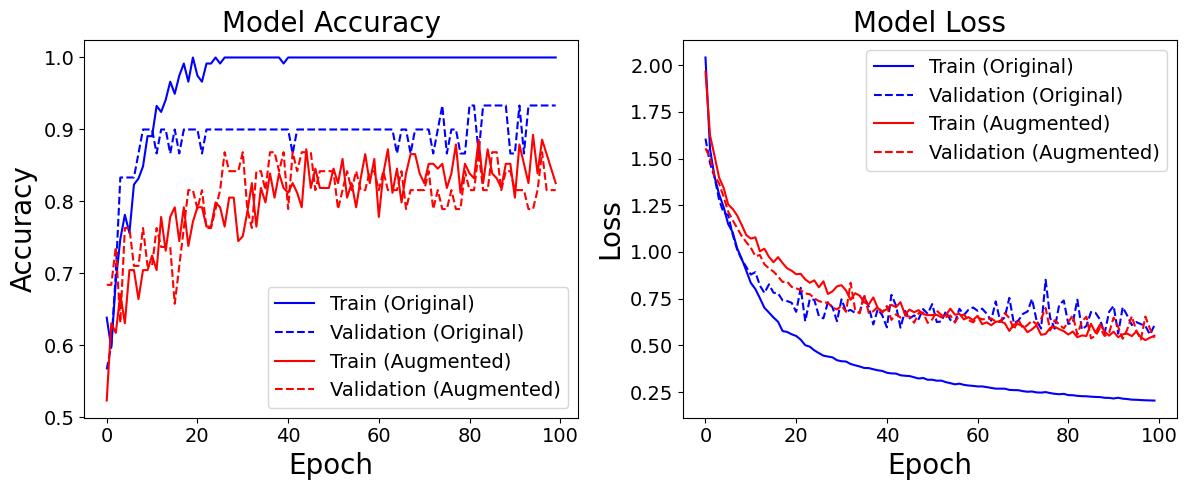

In [ ]:
# Plotting the training and validation curves
plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(history_original.history['accuracy'], color='blue')
plt.plot(history_original.history['val_accuracy'], color='blue', linestyle='--')
plt.plot(history_augmented.history['accuracy'], color='red')
plt.plot(history_augmented.history['val_accuracy'], color='red', linestyle='--')
plt.title('Model Accuracy', fontsize=20)
plt.xlabel('Epoch', fontsize=20)
plt.ylabel('Accuracy', fontsize=20)
plt.legend(['Train (Original)', 'Validation (Original)', 'Train (Augmented)', 'Validation (Augmented)'], loc='lower right', fontsize=14)
plt.tick_params(axis='both', which='major', labelsize=14)

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history_original.history['loss'], color='blue')
plt.plot(history_original.history['val_loss'], color='blue', linestyle='--')
plt.plot(history_augmented.history['loss'], color='red')
plt.plot(history_augmented.history['val_loss'], color='red', linestyle='--')
plt.title('Model Loss', fontsize=20)
plt.xlabel('Epoch', fontsize=20)
plt.ylabel('Loss', fontsize=20)
plt.legend(['Train (Original)', 'Validation (Original)', 'Train (Augmented)', 'Validation (Augmented)'], loc='upper right', fontsize=14)
plt.tick_params(axis='both', which='major', labelsize=14)

# Adjust layout to prevent overlapping
plt.tight_layout()

# Show the plot
plt.show()

**Fine-Tuning Pre Trained Model**

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_13 (InputLayer)          │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 224, 224, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 224, 224, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 112, 112, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 112, 112, 128)       │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 56, 56, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 56, 56, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 28, 28, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 28, 28, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 14, 14, 512)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 7, 7, 512)           │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_13 (InputLayer)          │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 224, 224, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 224, 224, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 112, 112, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 112, 112, 128)       │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 56, 56, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 56, 56, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 28, 28, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 28, 28, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 14, 14, 512)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 7, 7, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_13 (Flatten)                 │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_26 (Dense)                     │ (None, 256)                 │       6,422,784 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 33,984,584 (129.64 MB)

 Trainable params: 6,423,298 (24.50 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

 Optimizer params: 12,846,598 (49.01 MB)

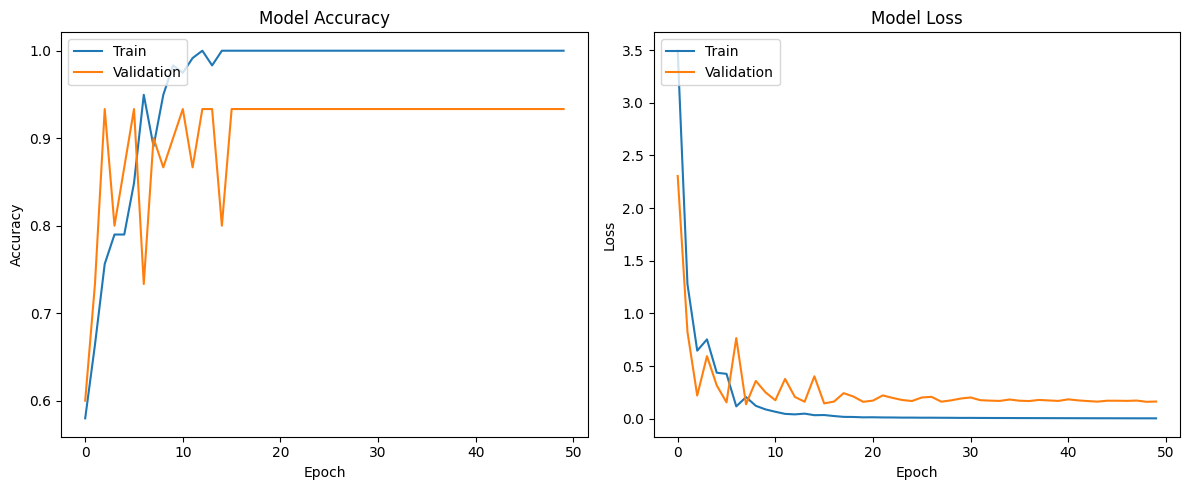

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 369ms/step
Accuracy: 0.8947368421052632
Precision: 0.8991596638655462
Recall: 0.8947368421052632
F1-Score: 0.8944444444444446
Average ROC AUC (OvR): 0.8947368421052632


Model: "functional_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_13 (InputLayer)          │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 224, 224, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 224, 224, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 112, 112, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 112, 112, 128)       │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 56, 56, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 56, 56, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 28, 28, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 28, 28, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 14, 14, 512)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 7, 7, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_13 (Flatten)                 │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_26 (Dense)                     │ (None, 256)                 │       6,422,784 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 21,137,988 (80.64 MB)

 Trainable params: 6,423,298 (24.50 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_13 (InputLayer)          │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 224, 224, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 224, 224, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 112, 112, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 112, 112, 128)       │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 56, 56, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 56, 56, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 28, 28, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 28, 28, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 14, 14, 512)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 7, 7, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_13 (Flatten)                 │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_26 (Dense)                     │ (None, 256)                 │       6,422,784 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 48,143,432 (183.65 MB)

 Trainable params: 13,502,722 (51.51 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

 Optimizer params: 27,005,446 (103.02 MB)

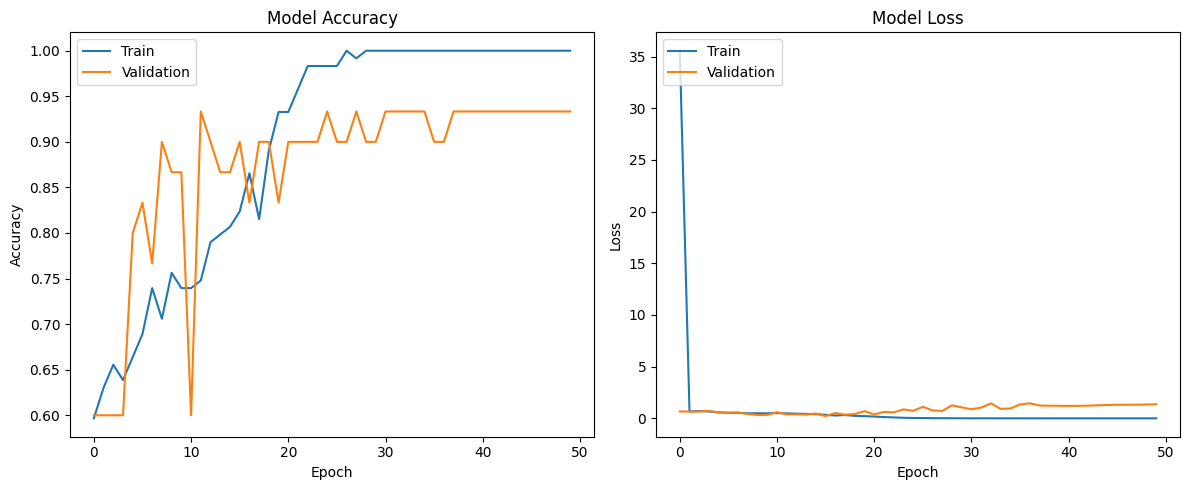

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 364ms/step
Accuracy: 0.7105263157894737
Precision: 0.7261904761904762
Recall: 0.7105263157894737
F1-Score: 0.7054263565891473
Average ROC AUC (OvR): 0.7105263157894737


In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
import tensorflow as tf
from keras.datasets import fashion_mnist
from keras.applications import VGG16
from keras.models import Model
from keras.layers import Dense, Flatten
from keras.utils import to_categorical

from tensorflow.keras.preprocessing.image import ImageDataGenerator

def add_noise(image):
    # Add noise
    noise = np.random.normal(loc=0.0, scale=0.05, size=image.shape)  # use scale to adjust intensity
    noisy_image = image + noise
    # Clip the image to be within valid pixel range [0, 1]
    noisy_image = np.clip(noisy_image, 0., 1.)
    return noisy_image

# Augmentation configuration
train_datagen = ImageDataGenerator(
    rotation_range=10,
    # width_shift_range=0.2,
    # height_shift_range=0.2,
    # shear_range=0.2,
    zoom_range=0.5,
    horizontal_flip=True,
    # vertical_flip=True,
    fill_mode='nearest',
    preprocessing_function=add_noise
)

# Split the data into training and testing sets
images_train, images_test, labels_train, labels_test = train_test_split(
    images, labels, test_size=0.2, random_state=42)

# Load pre-trained VGG16 model
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze all convolutional layers
for layer in base_model.layers:
    layer.trainable = False

base_model.summary()

# Add custom dense layers on top of VGG16
x = Flatten()(base_model.output)
x = Dense(256, activation='relu')(x)
output_layer = Dense(2, activation='softmax')(x)

# Create the transfer learning model
transfer_model = Model(inputs=base_model.input, outputs=output_layer)

# Compile the model
transfer_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train only the added Dense layers
# history = transfer_model.fit(images_train, labels_train, validation_split=0.2, epochs=50)
history = transfer_model.fit(train_datagen.flow(images_train, labels_train),
                    validation_data=(images_test, labels_test), epochs=50)#, validation_split=0.2)
history_transfer = history

# Save the transfer learning model
transfer_model.save('transfer_model.h5')

# Evaluate the performance on the test data
evaluation_result = transfer_model.evaluate(images_test, labels_test)
print("Test Accuracy after Transfer Learning with Frozen Convolutional Layers:", evaluation_result[1])

transfer_model.summary()

# Plotting the training and validation curves
plt.figure(figsize=(12, 5))


# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'], loc='upper left')

# Adjust layout to prevent overlapping
plt.tight_layout()

# Show the plot
plt.show()

labels_pred = transfer_model.predict(images_test)
labels_pred = np.argmax(labels_pred, axis=1)
labels_test_uncoded = np.argmax(labels_test, axis=1)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

accuracy = accuracy_score(labels_test_uncoded, labels_pred)
precision = precision_score(labels_test_uncoded, labels_pred, average='weighted')  # Adjust 'average' as needed
recall = recall_score(labels_test_uncoded, labels_pred, average='weighted')  # Adjust 'average' as needed
f1 = f1_score(labels_test_uncoded, labels_pred, average='weighted')  # Adjust 'average' as needed
roc_auc = roc_auc_score(labels_test_uncoded, labels_pred, multi_class='ovr')  # One-vs-Rest AUC

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1-Score: {f1}")
print(f"Average ROC AUC (OvR): {roc_auc}")




from keras.models import load_model

# Load the saved transfer learning model
transfer_model = load_model('transfer_model.h5')

# Display the model summary
transfer_model.summary()

# Unfreeze a few convolutional layers
for layer in transfer_model.layers[-5:]:
    layer.trainable = True

# Recompile the model after unfreezing layers
transfer_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the unfrozen convolutional layers and the dense layers
# history = transfer_model.fit(images_train, labels_train, validation_split=0.2, epochs=50)
history = transfer_model.fit(train_datagen.flow(images_train, labels_train),
                    validation_data=(images_test, labels_test), epochs=50)#, validation_split=0.2)
history_fine_tuned = history

# Evaluate the performance on the test data
evaluation_result = transfer_model.evaluate(images_test, labels_test)
print("Test Accuracy after Fine-Tuning:", evaluation_result[1])

transfer_model.summary()

# Plotting the training and validation curves
plt.figure(figsize=(12, 5))


# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'], loc='upper left')

# Adjust layout to prevent overlapping
plt.tight_layout()

# Show the plot
plt.show()

labels_pred = transfer_model.predict(images_test)
labels_pred = np.argmax(labels_pred, axis=1)
labels_test = np.argmax(labels_test, axis=1)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

accuracy = accuracy_score(labels_test, labels_pred)
precision = precision_score(labels_test, labels_pred, average='weighted')  # Adjust 'average' as needed
recall = recall_score(labels_test, labels_pred, average='weighted')  # Adjust 'average' as needed
f1 = f1_score(labels_test, labels_pred, average='weighted')  # Adjust 'average' as needed
roc_auc = roc_auc_score(labels_test, labels_pred, multi_class='ovr')  # One-vs-Rest AUC

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1-Score: {f1}")
print(f"Average ROC AUC (OvR): {roc_auc}")

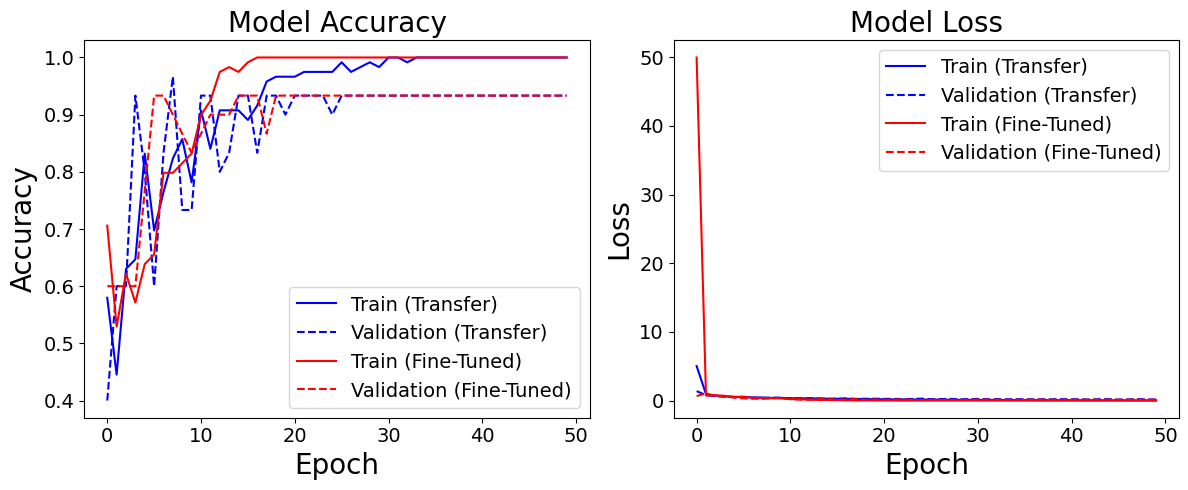

In [ ]:
# Plotting the training and validation curves
plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(history_transfer.history['accuracy'], color='blue')
plt.plot(history_transfer.history['val_accuracy'], color='blue', linestyle='--')
plt.plot(history_fine_tuned.history['accuracy'], color='red')
plt.plot(history_fine_tuned.history['val_accuracy'], color='red', linestyle='--')
plt.title('Model Accuracy', fontsize=20)
plt.xlabel('Epoch', fontsize=20)
plt.ylabel('Accuracy', fontsize=20)
plt.legend(['Train (Transfer)', 'Validation (Transfer)', 'Train (Fine-Tuned)', 'Validation (Fine-Tuned)'], loc='lower right', fontsize=14)
plt.tick_params(axis='both', which='major', labelsize=14)

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history_transfer.history['loss'], color='blue')
plt.plot(history_transfer.history['val_loss'], color='blue', linestyle='--')
plt.plot(history_fine_tuned.history['loss'], color='red')
plt.plot(history_fine_tuned.history['val_loss'], color='red', linestyle='--')
plt.title('Model Loss', fontsize=20)
plt.xlabel('Epoch', fontsize=20)
plt.ylabel('Loss', fontsize=20)
plt.legend(['Train (Transfer)', 'Validation (Transfer)', 'Train (Fine-Tuned)', 'Validation (Fine-Tuned)'], loc='upper right', fontsize=14)
plt.tick_params(axis='both', which='major', labelsize=14)

# Adjust layout to prevent overlapping
plt.tight_layout()

# Show the plot
plt.show()